# Python Project


I.Mô tả tập dữ liệu

1.Thông tin tổng quan:

Tên datasets: Traffic Flow data in Ho Chi Minh City, Viet Nam

Nguồn: https://www.kaggle.com/datasets/thanhnguyen2612/traffic-flow-data-in-ho-chi-minh-city-viet-nam

Mô tả ngắn gọn: Dữ liệu lịch sử về tình trạng giao thông ở thành phố HCM (tốc độ, mức độ dịch vụ, ...)

Thông tin từ trang chủ:

train.csv: được xây dựng từ `segments.csv` và `segment_status.csv`. Một ngày được chia thành 48 khoảng thời gian, mỗi khoảng dài 30 phút, khoảng đầu tiên là `period_0_00` tương ứng với `00:00` và khoảng cuối cùng là `period_23_30` tương ứng với `23:30`, mỗi khoảng được gán nhãn theo Mức độ Dịch vụ (LOS - được đánh giá bằng vận tốc tại thời điểm đó và vận tốc tối đa cho phép.)

Tập dữ liệu gốc được cung cấp và thu nhỏ cho mục đích phân tích chỉ chứa 4 bảng:

`segment_status.csv`: trạng thái giao thông của một đoạn đường được báo cáo tại các ngày và giờ khác nhau.
`segments.csv`: thông tin chi tiết về một đoạn đường bao gồm điểm bắt đầu, điểm kết thúc, chiều dài của đoạn đường và tên đường thuộc về nó.
`nodes.csv`: một node là một điểm trên Trái đất được xác định bằng vị trí kinh độ và vĩ độ, nó kết nối các đoạn đường lại với nhau.
`streets.csv`: nhiều đoạn đường cùng nhau tạo thành một con đường trong thế giới thực, bảng này chứa thông tin chi tiết về tên đường, cấp độ, loại đường và vận tốc tối đa khi lưu thông tự do.
1 số từ viết tắt trong bài:

LOS: level of service - mức độ dịch vụ - khái niệm được đánh giá theo vận tốc ở thời điểm đó và vận tốc tối đa cho phép trên 1 đoạn đường.

In [145]:
import kagglehub, os
import pandas as pd

SEED_RANDOM = 20251111
import numpy as np

In [146]:
# Download latest version
path = kagglehub.dataset_download("thanhnguyen2612/traffic-flow-data-in-ho-chi-minh-city-viet-nam")

print("Path to dataset files:", path)
print("Các files trong tập dữ liệu:", os.listdir(path))

Path to dataset files: /Users/nguyenphuoc/.cache/kagglehub/datasets/thanhnguyen2612/traffic-flow-data-in-ho-chi-minh-city-viet-nam/versions/6
Các files trong tập dữ liệu: ['segments.csv', 'nodes.csv', 'streets.csv', 'train.csv', 'segment_status.csv']


In [147]:
import pandas as pd

DECOR_FACTOR = 20
DECOR_LETTER = "="
NUM_OF_LINE = 5

BLUE = "\033[94m"
RED = "\033[91m"
RESET = "\033[0m"

BONUS_INFO_IF_SMALL = "\n"
SMALL_DEFINE = 11

def get_info(df: pd.DataFrame):
  print(f"\nSố dòng: {RED}{len(df):,}{RESET}, Số cột: {RED}{len(df.columns):,}{RESET}")

  for index, colum in enumerate(df.columns):
    NaN_exist = f"{RED}không có{RESET} giá trị null."
    null_count = 0
    if df[colum].isna().any():
      null_count = df[colum].isna().sum()
      NaN_exist = f"{RED}có {null_count}{RESET} giá trị null."

    BONUS_INFO_IF_SMALL = "\n"
    if len(set(df.get(colum))) <= SMALL_DEFINE:
      BONUS_INFO_IF_SMALL = f" Danh sách các giá trị khác nhau: \n{sorted(set(df.get(colum)))}\n"

    print(f"Cột ({index}) {BLUE}{colum}{RESET} có số phần tử: {RED}{len(df.get(colum)):,}{RESET} với {RED}{len(set(df.get(colum))):,}{RESET} giá trị khác nhau,\n{NaN_exist}{BONUS_INFO_IF_SMALL}")

In [148]:
train_csv_path = os.path.join(path, 'train.csv')
df_train = pd.read_csv(train_csv_path)
df_train.info()

get_info(df_train)

file_train_csv = os.path.basename(train_csv_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_train_csv} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_train.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33441 entries, 0 to 33440
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           33441 non-null  int64  
 1   segment_id    33441 non-null  int64  
 2   date          33441 non-null  object 
 3   weekday       33441 non-null  int64  
 4   period        33441 non-null  object 
 5   LOS           33441 non-null  object 
 6   s_node_id     33441 non-null  int64  
 7   e_node_id     33441 non-null  int64  
 8   length        33441 non-null  int64  
 9   street_id     33441 non-null  int64  
 10  max_velocity  4946 non-null   float64
 11  street_level  33441 non-null  int64  
 12  street_name   33440 non-null  object 
 13  street_type   33441 non-null  object 
 14  long_snode    33441 non-null  float64
 15  lat_snode     33441 non-null  float64
 16  long_enode    33441 non-null  float64
 17  lat_enode     33441 non-null  float64
dtypes: float64(5), int64(8), o

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,NaN,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771


In [149]:
display(df_train[df_train["street_name"].isnull()])

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
33440,33440,84535,2021-01-09,5,period_13_30,F,5140843585,6150226443,139,656562463,NaN,4,NaN,unclassified,106.828885,10.694142,106.827709,10.693657


Nhận xét về file train.csv của tác giả:

Ta thấy:
Cột (12) `street_name` có số phần tử: 33,441 với 696 giá trị khác nhau,
có 1 giá trị null.
khi in ra thì đó là:



In [150]:
display(df_train[df_train["street_name"].isnull()])

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
33440,33440,84535,2021-01-09,5,period_13_30,F,5140843585,6150226443,139,656562463,NaN,4,NaN,unclassified,106.828885,10.694142,106.827709,10.693657


Đường này theo toạ độ thuộc địa phận tỉnh Đồng nai, nên có thể xem là nhiễu trong bài toán xem xét về mật độ giao thông ở HCM. Nếu áp dụng các phương pháp gôm cụm thì sẽ không ảnh hưởng nếu gôm theo khoảng cách, vì điểm này sẽ nằm xa (về vị trí địa lý) so với các điểm khác.
và:

Cột (10) `max_velocity` có số phần tử: 33,441 với 28,506 giá trị khác nhau,
có 28495 giá trị null.
Dữ liệu trong tập datasets này được thu thập tại nội thành HCM trong thời gian từ 2020-2021, nên mặc định nếu NaN thì giá trị max_velocity = 40 (km/h)

### Xử lý missing values và outliers

Dưới đây xử lý dữ liệu thiếu và giá trị ngoại lai cho `df_train`:

In [151]:
# 1. Xử lý Missing Values
df_train_clean = df_train.copy()

# max_velocity: mặc định 40 km/h cho đường nội thành HCM (2020-2021)
df_train_clean["max_velocity"] = df_train_clean["max_velocity"].fillna(40)

# street_name: 1 dòng null - theo phân tích thuộc Đồng Nai (nhiễu), loại bỏ
n_before = len(df_train_clean)
df_train_clean = df_train_clean.dropna(subset=["street_name"])
n_dropped = n_before - len(df_train_clean)
print(f"Đã xử lý missing: fillna max_velocity=40, drop {n_dropped} dòng street_name null")
print(f"Số dòng sau xử lý: {len(df_train_clean):,}")
df_train_clean.isna().sum().sum()

Đã xử lý missing: fillna max_velocity=40, drop 1 dòng street_name null
Số dòng sau xử lý: 33,440


np.int64(0)

In [152]:
# 2. Phát hiện và xử lý Outliers (phương pháp IQR)
numeric_cols = ["length", "max_velocity", "long_snode", "lat_snode", "long_enode", "lat_enode"]

def detect_outliers_iqr(df, cols, factor=1.5):
    """Đánh dấu outliers: |x - median| > factor * IQR."""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        mask |= (df[col] < lower) | (df[col] > upper)
    return mask

outlier_mask = detect_outliers_iqr(df_train_clean, numeric_cols)
n_outliers = outlier_mask.sum()
print(f"Số dòng có ít nhất 1 outlier (IQR): {n_outliers:,} ({100*n_outliers/len(df_train_clean):.2f}%)")

# Loại bỏ outliers (hoặc giữ lại nếu muốn phân tích - comment dòng dưới để giữ)
df_train_clean = df_train_clean[~outlier_mask].reset_index(drop=True)
print(f"Số dòng sau loại outlier: {len(df_train_clean):,}")
df_train_clean.head()

Số dòng có ít nhất 1 outlier (IQR): 7,198 (21.53%)
Số dòng sau loại outlier: 26,242


,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
0,5,70,2020-08-02,6,period_23_30,D,5816921541,4614188871,8,32575864,40.0,3,Châu Văn Liêm,secondary,106.659032,10.751940,106.659019,10.752017
1,6,70,2020-08-03,0,period_0_00,E,5816921541,4614188871,8,32575864,40.0,3,Châu Văn Liêm,secondary,106.659032,10.751940,106.659019,10.752017
2,9,161,2020-09-11,4,period_0_30,A,3202462316,3202462317,21,32575935,40.0,3,Tân Phú,primary_link,106.723620,10.733619,106.723813,10.733604
3,10,173,2020-12-28,0,period_4_30,A,2299416638,4639027499,9,32575943,40.0,4,Lê Minh Xuân,tertiary,106.651613,10.786231,106.651699,10.786252
4,11,173,2020-12-28,0,period_7_30,A,2299416638,4639027499,9,32575943,40.0,4,Lê Minh Xuân,tertiary,106.651613,10.786231,106.651699,10.786252


### Chuyển đổi Timestamp thành Time Slots

Chuyển `period` thành `time_slot` (0–47: mỗi ngày 48 khoảng 30 phút).

In [153]:
# Chuyển period → time_slot (0-47, 48 slots/ngày 30 phút)
df_train_clean["hour"] = df_train_clean["period"].str.extract(r"period_(\d+)_").astype(int)
df_train_clean["minute"] = df_train_clean["period"].str.extract(r"period_\d+_(\d+)").astype(int)
df_train_clean["time_slot"] = df_train_clean["hour"] * 2 + (df_train_clean["minute"] // 30)

print("Time slot: 0 (00:00) → 47 (23:30)")
display(df_train_clean[["date", "period", "time_slot"]].head())

Time slot: 0 (00:00) → 47 (23:30)


,date,period,time_slot
0,2020-08-02,period_23_30,47
1,2020-08-03,period_0_00,0
2,2020-09-11,period_0_30,1
3,2020-12-28,period_4_30,9
4,2020-12-28,period_7_30,15


In [154]:
file_segments_path = os.path.join(path, 'segments.csv')
df_segments = pd.read_csv(file_segments_path)
df_segments.info()

get_info(df_segments)

file_segments_csv = os.path.basename(file_segments_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_segments_csv} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_segments.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84633 entries, 0 to 84632
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           84633 non-null  int64  
 1   created_at    84633 non-null  object 
 2   updated_at    84633 non-null  object 
 3   s_node_id     84633 non-null  int64  
 4   e_node_id     84633 non-null  int64  
 5   length        84633 non-null  int64  
 6   street_id     84633 non-null  int64  
 7   max_velocity  9871 non-null   float64
 8   street_level  84633 non-null  int64  
 9   street_name   84481 non-null  object 
 10  street_type   84633 non-null  object 
dtypes: float64(1), int64(6), object(4)
memory usage: 7.1+ MB

Số dòng: 84,633, Số cột: 11
Cột (0) _id có số phần tử: 84,633 với 84,633 giá trị khác nhau,
không có giá trị null.

Cột (1) created_at có số phần tử: 84,633 với 84,633 giá trị khác nhau,
không có giá trị null.

Cột (2) updated_at có số phần tử: 84,633 với 84,633 giá tr

,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
0,0,2020-10-18T13:26:17.365Z,2020-10-18T13:26:17.365Z,373543511,5468660805,114,31096786,80.0,1,Quốc Lộ 1,trunk
1,1,2020-10-18T13:26:17.400Z,2020-10-18T13:26:17.400Z,5468660805,5738158916,9,31096786,80.0,1,Quốc Lộ 1,trunk
2,2,2020-10-18T13:26:17.435Z,2020-10-18T13:26:17.435Z,5738158916,5738158918,23,31096786,80.0,1,Quốc Lộ 1,trunk
3,3,2020-10-18T13:26:17.444Z,2020-10-18T13:26:17.444Z,5738158918,5738158912,66,31096786,80.0,1,Quốc Lộ 1,trunk
4,4,2020-10-18T13:26:17.452Z,2020-10-18T13:26:17.452Z,5738158912,5758104203,127,31096786,80.0,1,Quốc Lộ 1,trunk


In [155]:
display(df_segments[df_segments["max_velocity"].isnull()].head(n=5))

,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
10,10,2020-10-18T13:26:17.486Z,2021-04-04T09:04:01.778Z,366459052,5764885888,108,32575737,NaN,4,Thương Mại,marketplace
11,11,2020-10-18T13:26:17.491Z,2021-04-04T09:04:03.289Z,5764885888,366459052,108,32575737,NaN,4,Xã Trung Chánh,unclassified
12,12,2020-10-18T13:26:17.495Z,2020-10-18T13:26:17.495Z,370818177,696860119,34,32575794,NaN,4,Chu Văn An,unclassified
13,13,2020-10-18T13:26:17.499Z,2020-10-18T13:26:17.499Z,696860119,370818177,34,32575794,NaN,4,Chu Văn An,unclassified
14,14,2020-10-18T13:26:17.503Z,2020-10-18T13:26:17.503Z,366450125,5627450801,13,32575820,NaN,4,Nguyễn Văn Bá,tertiary


In [156]:
display(df_segments[df_segments["street_name"].isnull()].head(5))

,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
25829,25829,2020-10-18T13:27:39.045Z,2021-04-04T16:48:51.105Z,1605303801,1605303786,214,147293393,NaN,4,NaN,unclassified
25830,25830,2020-10-18T13:27:39.047Z,2021-04-04T16:48:52.575Z,1605303786,1605303801,214,147293393,NaN,4,NaN,unclassified
25835,25835,2020-10-18T13:27:39.057Z,2021-04-04T16:49:01.115Z,1605303770,1605303803,523,147293399,NaN,4,NaN,unclassified
25836,25836,2020-10-18T13:27:39.059Z,2021-04-04T16:49:03.529Z,1605303803,1605303770,523,147293399,NaN,4,NaN,unclassified
25837,25837,2020-10-18T13:27:39.061Z,2021-04-04T16:49:04.942Z,1605303803,1605303768,245,147293399,NaN,4,NaN,unclassified


Nhận xét về file segments.csv:

Cột (9) street_name có số phần tử: 84,633 với 1,389 giá trị khác nhau,
có 152 giá trị null.
Thôn tin về tên đường bị trống, tuy nhiên trong file train.csv của tác giả đã tổng hợp, ta thấy street_name không trống, nên có thể tên đường được cập nhật từ thông tin trong nhiều file khác (street.csv), không chỉ riêng segments.csv

In [157]:
file_segment_status_path = os.path.join(path, 'segment_status.csv')
df_segment_status = pd.read_csv(file_segment_status_path)
df_segment_status.info()

get_info(df_segment_status)

file_segment_status = os.path.basename(file_segment_status_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_segment_status} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_segment_status.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90938 entries, 0 to 90937
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   _id         90938 non-null  int64 
 1   updated_at  90938 non-null  object
 2   segment_id  90938 non-null  int64 
 3   velocity    90938 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.8+ MB

Số dòng: 90,938, Số cột: 4
Cột (0) _id có số phần tử: 90,938 với 90,938 giá trị khác nhau,
không có giá trị null.

Cột (1) updated_at có số phần tử: 90,938 với 59,422 giá trị khác nhau,
không có giá trị null.

Cột (2) segment_id có số phần tử: 90,938 với 10,027 giá trị khác nhau,
không có giá trị null.

Cột (3) velocity có số phần tử: 90,938 với 179 giá trị khác nhau,
không có giá trị null.


 ==================== segment_status.csv ====================
In thử 5 dòng đầu tiên:



,_id,updated_at,segment_id,velocity
0,0,2020-07-03T14:55:31.869Z,24845,20
1,1,2020-07-03T15:02:56.048Z,33923,10
2,2,2020-07-04T08:15:52.696Z,33824,5
3,3,2020-07-04T08:15:59.903Z,33824,5
4,4,2020-07-04T08:16:08.201Z,33824,5


In [158]:
file_nodes_path = os.path.join(path, 'nodes.csv')
df_nodes = pd.read_csv(file_nodes_path)
df_nodes.info()

get_info(df_nodes)

file_nodes = os.path.basename(file_nodes_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_nodes} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_nodes.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577967 entries, 0 to 577966
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   _id     577967 non-null  int64  
 1   long    577967 non-null  float64
 2   lat     577967 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 13.2 MB

Số dòng: 577,967, Số cột: 3
Cột (0) _id có số phần tử: 577,967 với 577,967 giá trị khác nhau,
không có giá trị null.

Cột (1) long có số phần tử: 577,967 với 474,864 giá trị khác nhau,
không có giá trị null.

Cột (2) lat có số phần tử: 577,967 với 444,957 giá trị khác nhau,
không có giá trị null.


 ==================== nodes.csv ====================
In thử 5 dòng đầu tiên:



,_id,long,lat
0,366367223,106.629056,10.804243
1,366367233,106.709701,10.771110
2,366367242,106.737189,10.709337
3,366367274,106.760081,10.854489
4,366367285,106.721163,10.804994


In [159]:
file_streets_path = os.path.join(path, 'streets.csv')
df_streets = pd.read_csv(file_streets_path)
df_streets.info()

get_info(df_streets)

file_streets = os.path.basename(file_streets_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_streets} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_streets.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5553 entries, 0 to 5552
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           5553 non-null   int64  
 1   level         5553 non-null   int64  
 2   max_velocity  987 non-null    float64
 3   name          3948 non-null   object 
 4   type          5553 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 217.0+ KB

Số dòng: 5,553, Số cột: 5
Cột (0) _id có số phần tử: 5,553 với 5,553 giá trị khác nhau,
không có giá trị null.

Cột (1) level có số phần tử: 5,553 với 4 giá trị khác nhau,
không có giá trị null. Danh sách các giá trị khác nhau: 
[1, 2, 3, 4]

Cột (2) max_velocity có số phần tử: 5,553 với 4,577 giá trị khác nhau,
có 4566 giá trị null.

Cột (3) name có số phần tử: 5,553 với 1,049 giá trị khác nhau,
có 1605 giá trị null.

Cột (4) type có số phần tử: 5,553 với 11 giá trị khác nhau,
không có giá trị null. Danh sách các giá trị 

,_id,level,max_velocity,name,type
0,31096786,1,80.0,Quốc Lộ 1,trunk
1,32575737,4,NaN,NaN,unclassified
2,32575794,4,NaN,Chu Văn An,unclassified
3,32575820,4,NaN,Nguyễn Văn Bá,tertiary
4,32575823,4,NaN,Nguyễn Thị Nhỏ,tertiary


Nhận xét về file streets.csv của tác giả:

Ta thấy:
Cột (2) `max_velocity` có số phần tử: 5,553 với 4,577 giá trị khác nhau,
có 4566 giá trị null.

Cột (3) name có số phần tử: 5,553 với 1,049 giá trị khác nhau,
có 1605 giá trị null.
Như đã nói ở trên, `max_velocity` sẽ được mặc định là 40km/h nếu NaN.
name trong file này chính là `street_name`, tuy chỉ số này có nhiều giá trị NaN nhưng trong file tổng hợp train.csv của tác giả thì không, nên có thể tham khảo ở `train.csv` theo khoá _id


II.Chuẩn bị dữ liệu

1.Tạo lại file `train.csv`

(để xác thực với file `train.csv` hiện tại)

Chúng ta cần xác thực lại việc tạo ra file `train.csv` để đảm bảo thông tin trong `train.csv` có thể dùng được hoặc chỉnh sửa lại `train.csv` nếu quá trình tạo cần chỉnh sửa

1.1.Tạo lại file `train.csv` bằng pandas code python

In [160]:
from math import ceil
import collections

# Các hàm này tính theo công thức của tác giả tập datasets
# nhưng có chỉnh sửa vài chỗ

def transform_LOS(segment_id, velocity, segment_df):
    max_velocity = segment_df.loc[segment_id, "max_velocity"]
    if max_velocity is None:
        # Trong phiên bản gốc, tác giá mặc định là 50
        # sửa lại 40 để phù hợp với luật giao thông nội thành HCM (2020-2021)
        # như đã nói ở trên
        max_velocity = 40

    # Transform to label
    labels = ["A", "B", "C", "D", "E", "F"]
    threshold = 35
    if max_velocity >= 70:
        threshold = 45
    elif max_velocity >= 60:
        threshold = 40

    t = max(threshold - velocity, 0)
    return labels[min(ceil(t / 5), 5)]

def timestamp_to_time_slot(dt) -> int:
    """Chuyển datetime thành time_slot 0–47 (48 slots/ngày, mỗi slot 30 phút)."""
    if pd.isna(dt):
        return np.nan
    if not isinstance(dt, pd.Timestamp):
        dt = pd.to_datetime(dt)
    return dt.hour * 2 + (dt.minute // 30)

def transform_report(row, segment_df):
    """
    Biến đổi 1 dòng dữ liệu để trích xuất:
      - Ngày (date), dow (0-6), period, time_slot (0–47), LOS, day_type (weekday/weekend)
    """
    dt = row.get("updated_at")
    if pd.isna(dt):
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    if not isinstance(dt, pd.Timestamp):
        try:
            dt = pd.to_datetime(dt)
        except Exception:
            return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    h = dt.hour
    m = "00" if dt.minute < 30 else "30"
    p_name = f"period_{h}_{m}"
    time_slot = timestamp_to_time_slot(dt)
    LOS = transform_LOS(row["segment_id"], row["velocity"], segment_df)
    day_type = "weekend" if dt.weekday() >= 5 else "weekday"
    return dt.date(), dt.weekday(), p_name, time_slot, LOS, day_type

# ========================== cách chọn LOS ===========================
def major_voting(labels):
    '''
    Chọn nhãn LOS có tần suất xuất hiện cao nhất.
    Trong trường hợp có nhiều nhãn cùng có tần suất cao nhất (hòa),
    ưu tiên nhãn có mức độ dịch vụ tốt hơn (theo thứ tự trong los_order).

    Chú ý: hàm này là viết lại, hàm gốc của tác giả đã bị chỉnh sửa.
    cụ thể, hàm gốc là:

    def major_voting(labels):
      unique_labels = set(labels)
      count_labels = [labels.count(label) for label in unique_labels]

      sorted_labels = sorted(zip(unique_labels, count_labels), key=lambda x: x[1])
      if len(sorted_labels) > 1 and sorted_labels[0][1] == sorted_labels[1][1]:
          print("Oh no, many majors?")
      return sorted_labels[0][0]

    https://www.kaggle.com/code/thanhnguyen2612/this-is-how-to-label-and-transform-segment-reports

    chú ý đoạn này, hàm trả về LOS có tần suất xuất hiện ít nhất, thay vì cao nhất,
    do đó ta dùng phiên bản thay thế:

      sorted_labels = sorted(zip(unique_labels, count_labels), key=lambda x: x[1])
      if len(sorted_labels) > 1 and sorted_labels[0][1] == sorted_labels[1][1]:
          print("Oh no, many majors?")
      return sorted_labels[0][0]
    '''
    if not labels:
        return None  # Trả về None hoặc xử lý lỗi nếu danh sách rỗng

    counts = collections.Counter(labels)
    if not counts:
        return None # Xử lý trường hợp Counter rỗng (ví dụ: labels chứa toàn NaN)

    max_freq = max(counts.values())

    # Lấy tất cả các nhãn có tần suất xuất hiện cao nhất
    most_frequent_labels = [label for label, freq in counts.items() if freq == max_freq]

    # Định nghĩa thứ tự ưu tiên của các mức LOS để giải quyết trường hợp hòa
    # Sắp xếp như vầy để chủ đích tăng F, giảm E, D, C, B, A theo thứ tự nếu hoà.
    los_order = ["F", "E", "D", "C", "B", "A"]

    # Nếu chỉ có một nhãn có tần suất cao nhất, trả về nhãn đó
    if len(most_frequent_labels) == 1:
        return most_frequent_labels[0]
    else:
        # Nếu có trường hợp hòa, sắp xếp các nhãn đó theo thứ tự LOS và chọn nhãn đầu tiên (tốt nhất)
        most_frequent_labels.sort(key=lambda x: los_order.index(x))
        return most_frequent_labels[0]

def mean_voting(labels):
    '''
    Dùng mean để chọn LOS - file train.csv của tác giả dùng hàm này
    '''
    l = ["A", "B", "C", "D", "E", "F"]
    values = {"A":0, "B":1, "C":2, "D":3, "E":4, "F":5}
    mean = sum(values[label] for label in labels) / len(labels)
    return l[min(round(mean), 5)]

Nhận xét 1:

Chúng ta dùng `major_voting`, thay vì `mean_voting`
30 phút là 1 khoảng thời gian dài đối với đa số tình trạng kẹt xe (xe di chuyển chậm) ở nội thành HCM, nếu lấy trung bình, tín hiệu F có thể sẽ mất và chuyển thành E, D, C. Điều này cũng tốt, nhưng trong quan điểm phát hiện toàn bộ LOS F, thì major sẽ "cực đoan" hơn

In [161]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import os
import collections

# Thư mục chứa 4 file gốc
DATA_DIR = Path(path)
OUT_PATH = Path("./train_built.csv")

def parse_period_label(dt: pd.Timestamp) -> str:
    """Chuẩn 'period_H_MM' (MM ∈ {00,30})."""
    h = dt.hour
    m = 0 if dt.minute < 30 else 30
    return f"period_{h}_{m:02d}"

start_time = time.time()
segments = pd.read_csv(DATA_DIR / "segments.csv")
segstat  = pd.read_csv(DATA_DIR / "segment_status.csv")
nodes    = pd.read_csv(DATA_DIR / "nodes.csv")
streets  = pd.read_csv(DATA_DIR / "streets.csv")

# time features from segment_status.updated_at
dt_utc = pd.to_datetime(segstat["updated_at"], utc=True, errors="coerce")
dt = dt_utc

ss = segstat.copy()
ss["date"] = dt.dt.date.astype("string")
ss["dow"] = dt.dt.weekday
ss["period"] = dt.apply(parse_period_label)

# join segments + streets (coalesce street_name/type & max_velocity)
seg = segments.rename(columns={"_id": "segment_pk"})
strt = streets.rename(columns={"_id": "street_pk",
                               "name": "street_name",
                               "type": "street_type"})

# giữ các cột có tồn tại để tránh KeyError giữa các bản phát hành dataset
cols_seg = ["segment_pk","s_node_id","e_node_id","street_id","length","street_level","max_velocity","street_name","street_type"]
cols_seg = [c for c in cols_seg if c in seg.columns]

df = ss.merge(seg[cols_seg], left_on="segment_id", right_on="segment_pk", how="left")

str_small = strt[["street_pk","street_name","street_type","max_velocity"]].add_suffix("_str")
df = df.merge(str_small, left_on="street_id", right_on="street_pk_str", how="left")

# coalesce max_velocity: ưu tiên từ segments, thiếu thì dùng streets. Fill NaN cuối cùng bằng 40.
mv_seg = "max_velocity" if "max_velocity" in df.columns else None
mv_str = "max_velocity_str" if "max_velocity_str" in df.columns else None

# Trong khoảng thời gian dữ liệu miêu tả, vận tốc tối đa cho phép
# trên đường nội thành ở HCM là 40km/h. Do đó, dòng nào mà max_velocity NaN thì thay bằng 40
df["max_velocity_final"] = pd.Series(np.where(
    (mv_seg is not None) & df[mv_seg].notna(),
    df[mv_seg],
    df[mv_str] if (mv_str is not None) else np.nan
)).fillna(40)

# coalesce street_name/type
if ("street_name" in df.columns) or ("street_name_str" in df.columns):
    df["street_name_final"] = df.get("street_name").fillna(df.get("street_name_str"))
if ("street_type" in df.columns) or ("street_type_str" in df.columns):
    df["street_type_final"] = df.get("street_type").fillna(df.get("street_type_str"))

# add geo coords for s_node and e_node
nds = nodes.rename(columns={"_id":"node_id"})
nds_small = nds[["node_id","long","lat"]]

df = df.merge(nds_small.add_prefix("s_"), left_on="s_node_id", right_on="s_node_id", how="left")
df = df.merge(nds_small.add_prefix("e_"), left_on="e_node_id", right_on="e_node_id", how="left")

# ==== compute LOS then compress by period ====
# Chuẩn bị bảng tra max_velocity theo segment_id
# Dùng cột đã "coalesce": max_velocity_final (đặt tên map ra 'max_velocity')
segment_df = (
    df[["segment_id", "max_velocity_final"]]
    .dropna(subset=["segment_id"])
    .drop_duplicates("segment_id")
    .set_index("segment_id")
    .rename(columns={"max_velocity_final": "max_velocity"})
)

# Tính LOS cho từng bản ghi rồi nén (compress) theo (segment_id, date, dow, period)
tmp = df[["segment_id", "updated_at", "velocity"]].copy()
dates, weekdays, periods, time_slots, losses, day_types = [], [], [], [], [], []
for _, r in tmp.iterrows():
    d, wd, p, ts, los, day_type = transform_report(r, segment_df)
    dates.append(d); weekdays.append(wd); periods.append(p); time_slots.append(ts); losses.append(los); day_types.append(day_type)
tmp["date"] = dates
tmp["dow"] = weekdays
tmp["period"] = periods
tmp["time_slot"] = time_slots
tmp["LOS"] = losses
tmp["day_type"] = day_types
# print(losses)

df["LOS"] = tmp["LOS"].values
df["time_slot"] = tmp["time_slot"].values
df["day_type"] = tmp["day_type"].values

# finalize columns & export
rename_map = {
    "max_velocity_final":"max_velocity",
    "street_name_final":"street_name",
    "street_type_final":"street_type",
    "s_long":"long_snode",
    "s_lat":"lat_snode",
    "e_long":"long_enode",
    "e_lat":"lat_enode",
}

out_cols = [
    "segment_id","date","dow","day_type","period","time_slot","LOS",
    "s_node_id","e_node_id","length","street_id",
    "max_velocity_final","street_level",
    "street_name_final","street_type_final",
    "s_long","s_lat","e_long","e_lat",
]
out_cols = [c for c in out_cols if c in df.columns]

out = df[out_cols].rename(columns=rename_map).copy()
out = out.reset_index().rename(columns={"index":"_id"})

out.to_csv(OUT_PATH, index=False, encoding="utf-8")
print(f"Saved: {OUT_PATH} | rows={len(out)}")
print(f"Chạy trong {time.time() - start_time} s")

Saved: train_built.csv | rows=90938
Chạy trong 12.51891803741455 s


In [162]:
# Thay đổi đường dẫn để đọc file train_built.csv từ thư mục làm việc hiện tại
train_built_csv_path = './train_built.csv'
df_train_built = pd.read_csv(train_built_csv_path)
df_train_built.info()

get_info(df_train_built)

file_train_csv = os.path.basename(train_built_csv_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_train_csv} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_train_built.head(n=NUM_OF_LINE))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90938 entries, 0 to 90937
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           90938 non-null  int64  
 1   segment_id    90938 non-null  int64  
 2   date          90938 non-null  object 
 3   weekday       90938 non-null  int64  
 4   day_type      90938 non-null  object 
 5   period        90938 non-null  object 
 6   time_slot     90938 non-null  int64  
 7   LOS           90938 non-null  object 
 8   s_node_id     90938 non-null  int64  
 9   e_node_id     90938 non-null  int64  
 10  length        90938 non-null  int64  
 11  street_id     90938 non-null  int64  
 12  max_velocity  90938 non-null  float64
 13  street_level  90938 non-null  int64  
 14  street_name   90937 non-null  object 
 15  street_type   90938 non-null  object 
 16  long_snode    90938 non-null  float64
 17  lat_snode     90938 non-null  float64
 18  long_enode    90938 non-nu

,_id,segment_id,date,weekday,day_type,period,time_slot,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
0,0,24845,2020-07-03,4,weekday,period_14_30,29,D,2409410635,3771416347,73,138877181,40.0,2,Trường Chinh,primary,106.651961,10.793623,106.652559,10.793328
1,1,33923,2020-07-03,4,weekday,period_15_00,30,F,5769406275,5769406276,78,213726584,40.0,4,Lạc Long Quân,tertiary,106.651548,10.787537,106.651745,10.788215
2,2,33824,2020-07-04,5,weekend,period_8_00,16,F,2233730990,2299409160,67,213719139,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640
3,3,33824,2020-07-04,5,weekend,period_8_00,16,F,2233730990,2299409160,67,213719139,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640
4,4,33824,2020-07-04,5,weekend,period_8_00,16,F,2233730990,2299409160,67,213719139,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640


In [163]:
display(df_train_built[df_train_built["street_name"].isnull()])

,_id,segment_id,date,weekday,day_type,period,time_slot,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
81561,81561,84535,2021-01-09,5,weekend,period_13_30,27,F,5140843585,6150226443,139,656562463,40.0,4,NaN,unclassified,106.828885,10.694142,106.827709,10.693657


Nhận xét 2:

Ở trên chúng ta có 1 vấn đề với `street_name`, nhưng theo file tổng hợp này, thì `street_name` đã đầy đủ (như file `train.csv`)

In [164]:
# Convert the 'date' column to datetime objects
df_train_built["date"] = pd.to_datetime(df_train_built["date"])

date_min = df_train_built["date"].min().date()
date_max = df_train_built["date"].max().date()
# Use a list comprehension to extract years after converting to datetime
years = sorted({d.year for d in df_train_built["date"]})
# Format the dates to dd/mm/yyyy
date_min_formatted = date_min.strftime("%d/%m/%Y")
date_max_formatted = date_max.strftime("%d/%m/%Y")
print(f"Dữ liệu từ ngày: {date_min_formatted} tới ngày {date_max_formatted} (DD/MM/YYY) | years in data: {years}")


Dữ liệu từ ngày: 03/07/2020 tới ngày 22/04/2021 (DD/MM/YYY) | years in data: [2020, 2021]


1.2.Tạo lại file `train.csv` bằng pandas SQL

In [165]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import time
from math import ceil
import collections

start_time_sql = time.time()
DATA_DIR = Path(path)
OUT_PATH = Path("./train_built_sql.csv")

segments = pd.read_csv(DATA_DIR / "segments.csv")
segstat  = pd.read_csv(DATA_DIR / "segment_status.csv")
nodes    = pd.read_csv(DATA_DIR / "nodes.csv")
streets  = pd.read_csv(DATA_DIR / "streets.csv")

dt_utc = pd.to_datetime(segstat["updated_at"], utc=True, errors="coerce")
dt = dt_utc

def parse_period_label(dt: pd.Timestamp) -> str:
    h = dt.hour
    m = 0 if dt.minute < 30 else 30
    return f"period_{h}_{m:02d}"

def timestamp_to_time_slot(dt) -> int:
    if pd.isna(dt): return np.nan
    if not isinstance(dt, pd.Timestamp): dt = pd.to_datetime(dt)
    return dt.hour * 2 + (dt.minute // 30)

ssp = segstat.copy()
ssp["date"] = dt.dt.date.astype("string")
ssp["dow"] = dt.dt.weekday
ssp["period"] = dt.apply(parse_period_label)
ssp["time_slot"] = dt.apply(timestamp_to_time_slot)

con = sqlite3.connect(":memory:")

ssp.to_sql("segment_status_prepared", con, index=False)
segments.to_sql("segments", con, index=False)
nodes.to_sql("nodes", con, index=False)
streets.to_sql("streets", con, index=False)

sql = """
WITH seg AS (
    SELECT
        s._id AS segment_pk,
        s.s_node_id, s.e_node_id,
        s.street_id,
        s.length,
        s.street_level,
        s.max_velocity AS seg_max_velocity,
        s.street_name AS seg_street_name,
        s.street_type AS seg_street_type
    FROM segments s
),
st AS (
    SELECT
        t._id AS street_pk,
        t.name AS street_name,
        t.type AS street_type,
        t.max_velocity AS str_max_velocity
    FROM streets t
),
ssp AS (
    SELECT
        segment_id, date, dow, period, time_slot, velocity
    FROM segment_status_prepared
),
joined AS (
    SELECT
        ssp.segment_id,
        ssp.date, ssp.dow, ssp.period, ssp.time_slot,
        COALESCE(seg.seg_street_name, st.street_name) AS street_name,
        COALESCE(seg.seg_street_type, st.street_type) AS street_type,
        COALESCE(seg.seg_max_velocity, st.str_max_velocity) AS max_velocity,
        seg.street_level,
        seg.street_id,
        seg.length,
        seg.s_node_id, seg.e_node_id,
        ssp.velocity
    FROM ssp
    LEFT JOIN seg ON ssp.segment_id = seg.segment_pk
    LEFT JOIN st  ON seg.street_id  = st.street_pk
),
s_coords AS (
    SELECT _id AS node_id, long AS s_long, lat AS s_lat
    FROM nodes
),
e_coords AS (
    SELECT _id AS node_id, long AS e_long, lat AS e_lat
    FROM nodes
)
SELECT
    j.segment_id,
    j.date, j.dow, j.period, j.time_slot,
    NULL AS LOS,  -- sẽ tính sau bằng Python
    j.s_node_id, j.e_node_id,
    j.length,
    j.street_id,
    j.max_velocity,
    j.street_level,
    j.street_name, j.street_type,
    s_coords.s_long AS long_snode, s_coords.s_lat AS lat_snode,
    e_coords.e_long AS long_enode, e_coords.e_lat AS lat_enode,
    j.velocity
FROM joined j
LEFT JOIN s_coords ON j.s_node_id = s_coords.node_id
LEFT JOIN e_coords ON j.e_node_id = e_coords.node_id
;
"""

out_sql = pd.read_sql_query(sql, con)
con.close()

# Điền mặc định max_velocity = 40 nếu còn thiếu (đúng giả định nội thành HCM)
out_sql["max_velocity"] = out_sql["max_velocity"].fillna(40)

# Bảng tra max_velocity theo segment_id (nếu cần tra nhanh trong hàm)
# Ở đây dùng map cho nhanh, nhưng không bắt buộc phải truy vấn theo segment_id trong hàm nữa
seg_mv = (
    out_sql[["segment_id", "max_velocity"]]
    .dropna(subset=["segment_id"])
    .drop_duplicates("segment_id")
    .set_index("segment_id")
)

# Tính LOS cho từng bản ghi & gán trực tiếp (KHÔNG groupby/merge)
out_sql["LOS"] = out_sql.apply(
    lambda r: transform_LOS(r["segment_id"], r["velocity"], seg_mv),
    axis=1
).astype("category")
out_sql["day_type"] = np.where(out_sql["dow"] >= 5, "weekend", "weekday")

# save to CSV
out_sql = out_sql.reset_index().rename(columns={"index":"_id"})
out_sql.to_csv(OUT_PATH, index=False, encoding="utf-8")
print(f"Saved: {OUT_PATH} | rows={len(out_sql)}")
print(f"Chạy trong: {time.time() - start_time_sql:.2f}s")

Saved: train_built_sql.csv | rows=90938
Chạy trong: 1.85s


In [166]:
train_built_sql_csv_path = './train_built_sql.csv'
df_train_built_sql = pd.read_csv(train_built_sql_csv_path)
df_train_built_sql.info()

get_info(df_train_built_sql)

file_train_csv = os.path.basename(train_built_sql_csv_path)
print(f"\n {DECOR_LETTER * DECOR_FACTOR} {file_train_csv} {DECOR_LETTER * DECOR_FACTOR}")
print(f"In thử {NUM_OF_LINE} dòng đầu tiên:\n")
display(df_train_built_sql.head(n=NUM_OF_LINE))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90938 entries, 0 to 90937
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           90938 non-null  int64  
 1   segment_id    90938 non-null  int64  
 2   date          90938 non-null  object 
 3   weekday       90938 non-null  int64  
 4   period        90938 non-null  object 
 5   time_slot     90938 non-null  int64  
 6   LOS           90938 non-null  object 
 7   s_node_id     90938 non-null  int64  
 8   e_node_id     90938 non-null  int64  
 9   length        90938 non-null  int64  
 10  street_id     90938 non-null  int64  
 11  max_velocity  90938 non-null  float64
 12  street_level  90938 non-null  int64  
 13  street_name   90937 non-null  object 
 14  street_type   90938 non-null  object 
 15  long_snode    90938 non-null  float64
 16  lat_snode     90938 non-null  float64
 17  long_enode    90938 non-null  float64
 18  lat_enode     90938 non-nu

,_id,segment_id,date,weekday,period,time_slot,LOS,s_node_id,e_node_id,length,...,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,velocity,day_type
0,0,24845,2020-07-03,4,period_14_30,29,D,2409410635,3771416347,73,...,40.0,2,Trường Chinh,primary,106.651961,10.793623,106.652559,10.793328,20,weekday
1,1,33923,2020-07-03,4,period_15_00,30,F,5769406275,5769406276,78,...,40.0,4,Lạc Long Quân,tertiary,106.651548,10.787537,106.651745,10.788215,10,weekday
2,2,33824,2020-07-04,5,period_8_00,16,F,2233730990,2299409160,67,...,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640,5,weekend
3,3,33824,2020-07-04,5,period_8_00,16,F,2233730990,2299409160,67,...,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640,5,weekend
4,4,33824,2020-07-04,5,period_8_00,16,F,2233730990,2299409160,67,...,40.0,4,Đường Phú Hòa,residential,106.654482,10.785806,106.653887,10.785640,5,weekend


1.3.So sánh file `train.csv` và 2 file train tự build

In [167]:
import pandas as pd

def compare_csv(file1_path, file2_path,
                out_diff_rows="diff_rows.csv",
                out_diff_cells="diff_cells.csv"):

    # Load
    df1 = pd.read_csv(file1_path)
    df2 = pd.read_csv(file2_path)
    # Cột velocity được thêm vào trong quá trình tạo, nên drop ra
    df2.drop(columns=["velocity"], inplace=True)

    # Kiểm tra shape
    if df1.shape != df2.shape:
        print(" Hai file khác kích thước:", df1.shape, df2.shape)
        return None

    print(f"Shape: {df1.shape}")

    # ------- 1) Chuẩn hóa để NaN == NaN -------
    df1_filled = df1.fillna("<<NAN>>")
    df2_filled = df2.fillna("<<NAN>>")

    # ------- 2) Compare cell-by-cell -------
    cell_equal = df1_filled.eq(df2_filled)   # True/False từng ô
    row_equal = cell_equal.all(axis=1)

    # ------- 3) Lấy danh sách dòng khác -------
    diff_row_indices = row_equal[~row_equal].index.tolist()

    print(f"Số dòng giống nhau: {row_equal.sum()}")
    print(f"Số dòng khác nhau: {len(diff_row_indices)}")

    if len(diff_row_indices) == 0:
        print("   => Hai file giống nhau hoàn toàn.")
        return None

    # ------- 4) Xuất report dòng khác -------
    diff_rows = df1.loc[diff_row_indices].copy()
    diff_rows.to_csv(out_diff_rows, index=False)
    print(f"Đã xuất diff_rows → {out_diff_rows}")

    # ------- 5) Xuất report cell khác (True = giống, False = khác) -------
    diff_cells = cell_equal.loc[diff_row_indices]
    diff_cells.to_csv(out_diff_cells, index=False)
    print(f"Đã xuất diff_cells → {out_diff_cells}")

    # ------- 6) In chi tiết từng dòng -------
    print("\n===== CHI TIẾT TỪNG DÒNG KHÁC =====")
    for idx in diff_row_indices:
        print(f"\n--- Dòng {idx} khác ---")
        col_diff = cell_equal.loc[idx] == False
        diff_columns = col_diff[col_diff].index.tolist()
        print("Các cột khác:", diff_columns)

        print("\nGiá trị file1:")
        print(df1.loc[idx, diff_columns])

        print("\nGiá trị file2:")
        print(df2.loc[idx, diff_columns])

    return {
        "diff_row_count": len(diff_row_indices),
        "diff_rows": diff_rows,
        "diff_cells": diff_cells
    }

result = compare_csv("./train_built.csv", "./train_built_sql.csv")

Shape: (90938, 20)
Số dòng giống nhau: 90938
Số dòng khác nhau: 0
   => Hai file giống nhau hoàn toàn.


In [168]:
import pandas as pd
from pathlib import Path

train   = pd.read_csv(os.path.join(path, "train.csv"))
built_a = pd.read_csv("./train_built.csv")        # bản pandas
built_b = pd.read_csv("./train_built_sql.csv")    # bản SQL

for df in (train, built_a, built_b):
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date.astype("string")

key = ["segment_id","date","period"]

def summarize(df, name):
    n = len(df)
    nunique = df[key].dropna().drop_duplicates().shape[0]
    dup = n - nunique
    return {"name": name, "rows": n, "unique_keys": nunique, "duplicate_rows_by_key": dup}

summary = pd.DataFrame([
    summarize(train, "train.csv"),
    summarize(built_a, "train_built.csv"),
    summarize(built_b, "train_built_sql.csv"),
])
summary

,name,rows,unique_keys,duplicate_rows_by_key
0,train.csv,33441,33441,0
1,train_built.csv,90938,33441,57497
2,train_built_sql.csv,90938,33441,57497


In [169]:
def coverage(train_df, other_df, label):
    a = set(map(tuple, train_df[key].dropna().to_records(index=False)))
    b = set(map(tuple, other_df[key].dropna().to_records(index=False)))
    return {
        "built": label,
        "train_keys": len(a),
        "built_keys": len(b),
        "common_keys": len(a & b),
        "missing_in_built": len(a - b),
        "extra_only_in_built": len(b - a),
        "coverage_pct": round(100*len(a & b)/max(1,len(a)),2)
    }

pd.DataFrame([
    coverage(train, built_a, "train_built.csv"),
    coverage(train, built_b, "train_built_sql.csv"),
])

,built,train_keys,built_keys,common_keys,missing_in_built,extra_only_in_built,coverage_pct
0,train_built.csv,33441,33441,33441,0,0,100.0
1,train_built_sql.csv,33441,33441,33441,0,0,100.0


In [170]:
def duplicate_examples(df):
    dup_mask = df.duplicated(subset=key, keep=False)
    dups = df.loc[dup_mask, key].value_counts().reset_index(name="count")
    return dups.sort_values("count", ascending=False).head(5)

dups_a = duplicate_examples(built_a)
dups_b = duplicate_examples(built_b)

display(dups_a)  # top 5 key trùng trong train_built.csv
display(dups_b)  # top 5 key trùng trong train_built_sql.csv

,segment_id,date,period,count
0,69363,2020-12-06,period_12_30,225
4,69363,2020-12-06,period_11_00,225
5,18274,2020-12-06,period_6_00,225
1,18274,2020-12-06,period_5_00,225
3,69363,2020-12-06,period_9_00,225


,segment_id,date,period,count
0,69363,2020-12-06,period_12_30,225
4,69363,2020-12-06,period_11_00,225
5,18274,2020-12-06,period_6_00,225
1,18274,2020-12-06,period_5_00,225
3,69363,2020-12-06,period_9_00,225


Nhận xét:

Về số cột, cả 3 file có tính tương đồng (đủ cột).
Về số dòng, hai file tạo ra có số dòng lớn hơn file gốc của tác giả, bởi vì tập dữ liệu này xây dựng theo hướng thiết bị cuối gửi data về cho trung tâm, với tần suất hơn 1 lần mỗi 30 phút, nghĩa là trong 1 khung thời gian 30 phút có thể nhận nhiều hơn 1 data cho 1 đoạn đường. Ở file gốc, tác giả đã dùng mean_voting() để chọn 1 dòng data đại diện cho 1 khung thời gian. Trong thực tế vẫn ổn dù LOS có tính categorical, bởi vì 30 phút là 1 khoảng thời gian đủ dài so với những trường hợp kẹt xe trong nội thành HCM. Và với nhiều giá trị cùng tới trong khoảng 30 phút, có thể trường hợp kẹt xe/ "xe di chuyển chậm" đã được giải quyết ở những giá trị sau, nên việc tính mean là hợp lý.
Tuy nhiên ở đây, chúng ta sẽ dùng mode/ major_voting() như đã bàn ở nhận xét trên. Nghĩa là từ bây giờ, tín hiệu LOS xuất hiện nhiều nhất ở 1 đoạn đường trong 1 khung giờ cố định sẽ là tín hiệu đại diện cho đoạn đường đó trong khung giờ đó.

1.4.Thống kê lai các LOS theo major_voting

In [171]:
import pandas as pd
import collections

IN_PATH  = "./train_built_sql.csv"
OUT_PATH = "./train_built_compact.csv"

# Đọc file đã build
df = pd.read_csv(IN_PATH)

key = ["segment_id", "date", "dow", "period"]

# Nén LOS theo nhóm + số bản ghi trước nén
los_compact = (
    df.groupby(key, as_index=False)
      .agg(LOS=("LOS", lambda s: major_voting(list(s))),
           n=("LOS", "size"))
)

# Lấy các cột “tĩnh” đại diện cho mỗi khóa (giữ .first())
#    Chỉ liệt kê các cột bạn muốn giữ lại trong bản nén.
static_cols = [
    "day_type","time_slot","s_node_id","e_node_id","length","street_id","max_velocity","street_level",
    "street_name","street_type","long_snode","lat_snode","long_enode","lat_enode"
]
static_cols = [c for c in static_cols if c in df.columns]

static_compact = (
    df[key + static_cols]
      .drop_duplicates()
      .groupby(key, as_index=False)
      .first()
)

# Hợp nhất: 1 dòng / key, có LOS (voted) + n + các cột tĩnh
df_compact = static_compact.merge(los_compact, on=key, how="left", validate="one_to_one")

out_cols = [c for c in [
    "segment_id","date","dow","day_type","period","time_slot","LOS","n",
    "s_node_id","e_node_id","length","street_id","max_velocity","street_level",
    "street_name","street_type","long_snode","lat_snode","long_enode","lat_enode"
] if c in df_compact.columns]

df_compact = df_compact[out_cols].copy()
df_compact.to_csv(OUT_PATH, index=False, encoding="utf-8")

print("Rows before:", len(df))
print("Rows after :", len(df_compact))
print("Saved to   :", OUT_PATH)

Rows before: 90938
Rows after : 33441
Saved to   : ./train_built_compact.csv


In [172]:
train.LOS.value_counts()

LOS
A    13278
B     4700
F     4089
C     3839
E     3828
D     3707
Name: count, dtype: int64

In [173]:
pd.read_csv("./train_built_compact.csv").LOS.value_counts()

LOS
A    13325
F     9151
B     4850
D     2115
C     2098
E     1902
Name: count, dtype: int64

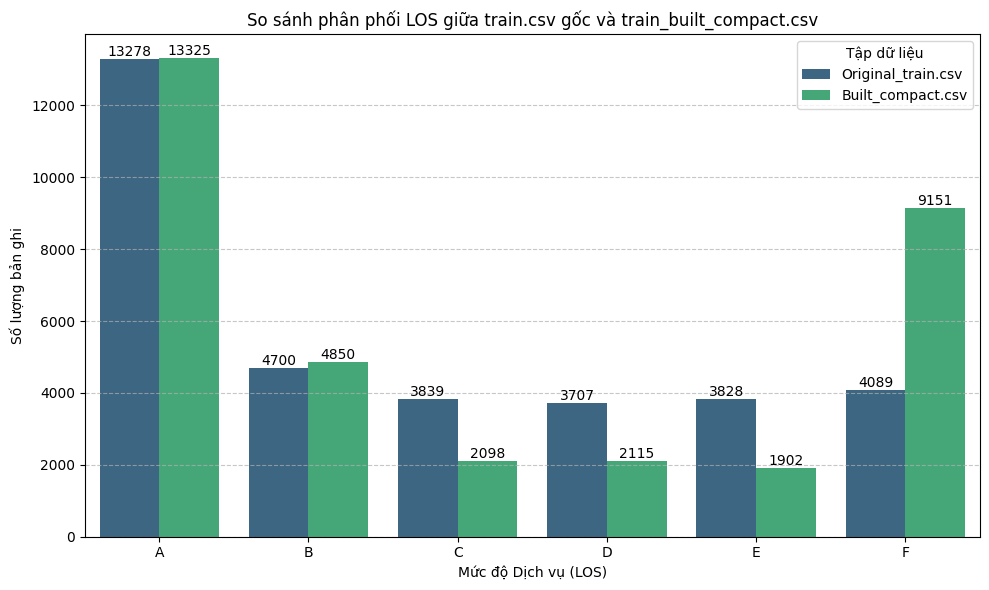


Bảng số liệu LOS Counts:


,LOS,Original_train.csv,Built_compact.csv
0,A,13278,13325
1,B,4700,4850
2,C,3839,2098
3,D,3707,2115
4,E,3828,1902
5,F,4089,9151


In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tải lại df_train (tương ứng với train.csv) nếu chưa có
# path biến global đã được định nghĩa từ đầu notebook
try:
    if 'df_train' not in locals():
        df_train = pd.read_csv(os.path.join(path, 'train.csv'))
except NameError:
    print("Lỗi: Biến 'path' chưa được định nghĩa. Đảm bảo các ô trước đã chạy.")
    # Fallback nếu 'path' không có sẵn
    df_train = pd.read_csv('train.csv') # Giả định train.csv nằm trong thư mục hiện tại

# Tải lại df_compact (tương ứng với train_built_compact.csv) nếu chưa có
try:
    if 'df_compact' not in locals():
        df_compact = pd.read_csv('./train_built_compact.csv')
except FileNotFoundError:
    print("Lỗi: Không tìm thấy 'train_built_compact.csv'. Đảm bảo các ô tạo file đã chạy.")
    # Fallback hoặc xử lý lỗi khác
    df_compact = pd.DataFrame(columns=['LOS']) # Tạo DataFrame rỗng để tránh lỗi tiếp theo

# Định nghĩa thứ tự của LOS
los_order = ["A", "B", "C", "D", "E", "F"]

# Lấy value_counts cho LOS từ cả hai DataFrame
los_original_counts = df_train['LOS'].value_counts().reindex(los_order, fill_value=0)
los_built_counts = df_compact['LOS'].value_counts().reindex(los_order, fill_value=0)

# Tạo DataFrame để dễ dàng vẽ biểu đồ so sánh
comparison_df = pd.DataFrame({
    'Original_train.csv': los_original_counts,
    'Built_compact.csv': los_built_counts
}).reset_index()
# The column created by reset_index is already named 'LOS' because the Series index was named 'LOS'.
# So, we should just ensure it's named 'LOS' or explicitly rename it if we wanted a different name.
# For melt, we will use 'LOS' as id_vars.

# Chuyển đổi DataFrame sang định dạng long để sử dụng seaborn.barplot dễ hơn
comparison_df_melted = comparison_df.melt(id_vars='LOS', var_name='Dataset', value_name='Count')

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=comparison_df_melted, x='LOS', y='Count', hue='Dataset', order=los_order, palette='viridis')

# Thêm số liệu ngay trên mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('So sánh phân phối LOS giữa train.csv gốc và train_built_compact.csv')
plt.xlabel('Mức độ Dịch vụ (LOS)')
plt.ylabel('Số lượng bản ghi')
plt.legend(title='Tập dữ liệu')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu
print("\nBảng số liệu LOS Counts:")
display(comparison_df)

Nhận xét:

ta thấy nếu dùng major_voting, các LOS sẽ phân bố khác, dễ thấy nhất là F.
Và tất nhiên các trường hợp F mới chính là các trường hợp C, D, E cũ (mà trước đó dùng mean sẽ dễ tạo ra). Nên số trường hợp C, D, E giảm.
Về tương quan các LOS, ta thấy phân bổ gần giống nhau trừ các trường hợp trên, nên các tính major_voting cũng không tạo ra đột biến gì trong dữ liệu. Nhưng có ý nghĩa/ quan điểm tìm kiếm giá trị F cực đoan hơn, phù hợp với cách hiện tại. Do đó ta giữ cách chọn major_voting.


2.Kiểm tra độ lệch dữ liệu

In [175]:
# Convert the 'date' column to datetime objects
df_train_built["date"] = pd.to_datetime(df_train_built["date"])

date_min = df_train_built["date"].min().date()
date_max = df_train_built["date"].max().date()
# Use a list comprehension to extract years after converting to datetime
years = sorted({d.year for d in df_train_built["date"]})
# Format the dates to dd/mm/yyyy
date_min_formatted = date_min.strftime("%d/%m/%Y")
date_max_formatted = date_max.strftime("%d/%m/%Y")
print(f"Dữ liệu từ ngày: {date_min_formatted} tới ngày {date_max_formatted} (DD/MM/YYY) | years in data: {years}")


Dữ liệu từ ngày: 03/07/2020 tới ngày 22/04/2021 (DD/MM/YYY) | years in data: [2020, 2021]


Lưu ý về thời gian của dữ liệu:

Dữ liệu từ ngày: 03/07/2020 tới ngày 22/04/2021 (DD/MM/YYY) | years in data: [2020, 2021]
Đây là khoảng thời gian có rất nhiều biến động tới tình hình lưu lượng giao thông, bao gồm:
ngày nghỉ, lễ, tết
Covid


2.1.Lệch theo khung giờ

In [176]:
import pandas as pd
import numpy as np
from datetime import timedelta, date

# Load
df = pd.read_csv("./train_built_compact.csv")

# Chuẩn hoá cột date và rút trích thời gian
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["hour"]   = df["period"].str.extract(r"period_(\d+)_").astype(int)
df["minute"] = df["period"].str.extract(r"period_\d+_(\d+)").astype(int)
df["time_slot"] = df["hour"] * 2 + (df["minute"] // 30)  # 0..47

# dow = day of week (0=Mon..6=Sun).
if "dow" in df.columns and df["dow"].notna().all():
    df["dow"] = df["dow"].astype(int)
# else:
#     df["dow"] = df["date"].dt.weekday

# Phân loại: weekdays (Mon–Fri) vs weekend (Sat + Sun)
df["day_type"] = np.where(df["dow"] >= 5, "weekend", "weekday")

# Giữ LOS dạng category (để xử lý mode chữ) và bản số (nếu cần)
los_order = ["A","B","C","D","E","F"]
df["LOS"] = pd.Categorical(df["LOS"], categories=los_order, ordered=True)

def mode_label(s: pd.Series):
    """Mode cho nhãn (ưu tiên nhãn chữ). Trả về NaN nếu trống."""
    if s.empty:
        return np.nan
    m = s.mode(dropna=True)
    return m.iat[0] if len(m) else np.nan

In [177]:
import pandas as pd

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract hour & minute from period
df["hour"] = df["period"].str.extract(r"period_(\d+)_").astype(int)
df["minute"] = df["period"].str.extract(r"period_\d+_(\d+)").astype(int)

# slot index (0–47)
df["time_slot"] = df["hour"] * 2 + (df["minute"] // 30)
df.sort_values("time_slot")

,segment_id,date,weekday,day_type,period,time_slot,LOS,n,s_node_id,e_node_id,...,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,hour,minute
16720,41654,2020-08-03,0,weekday,period_0_00,0,F,8,4217007492,4217006583,...,40.0,4,Lạc Long Quân,tertiary,106.642441,10.767065,106.642345,10.766973,0,0
16536,41607,2020-08-03,0,weekday,period_0_00,0,F,8,3718439602,4948305011,...,40.0,3,Âu Cơ,secondary,106.650634,10.770778,106.650379,10.771152,0,0
3335,7016,2020-08-03,0,weekday,period_0_00,0,F,8,5045657029,5045657134,...,40.0,4,Trần Nhân Tôn,tertiary,106.674581,10.763541,106.674589,10.763485,0,0
16538,41608,2020-08-03,0,weekday,period_0_00,0,F,8,3718439602,4102230906,...,40.0,3,Âu Cơ,secondary,106.650634,10.770778,106.650948,10.770302,0,0
3333,7015,2020-08-03,0,weekday,period_0_00,0,F,8,5045657134,5045657029,...,40.0,4,Trần Nhân Tôn,tertiary,106.674589,10.763485,106.674581,10.763541,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30317,70456,2020-08-02,6,weekend,period_23_30,47,F,2,5598917002,5794771153,...,40.0,4,Nguyễn Chí Thanh,tertiary,106.673228,10.760826,106.673125,10.760806,23,30
30315,70455,2020-08-02,6,weekend,period_23_30,47,E,2,5598917001,5598917002,...,40.0,4,Nguyễn Chí Thanh,tertiary,106.673373,10.760848,106.673228,10.760826,23,30
14800,37057,2020-08-02,6,weekend,period_23_30,47,F,2,2302085871,2302085856,...,40.0,3,Huỳnh Tấn Phát,primary_link,106.727999,10.752632,106.728222,10.752513,23,30
14875,37420,2020-11-30,0,weekday,period_23_30,47,A,1,2079964957,2079964991,...,40.0,2,Cộng Hòa,primary,106.660862,10.800856,106.660691,10.800874,23,30


In [178]:
slot_counts = df["time_slot"].value_counts().sort_index()

slot_table = pd.DataFrame({
    "time_slot": range(48),
    "count_records": [slot_counts.get(i, 0) for i in range(48)]
})

slot_table

,time_slot,count_records
0,0,4383
1,1,1007
2,2,686
3,3,896
4,4,743
5,5,194
6,6,559
7,7,989
8,8,824
9,9,1004


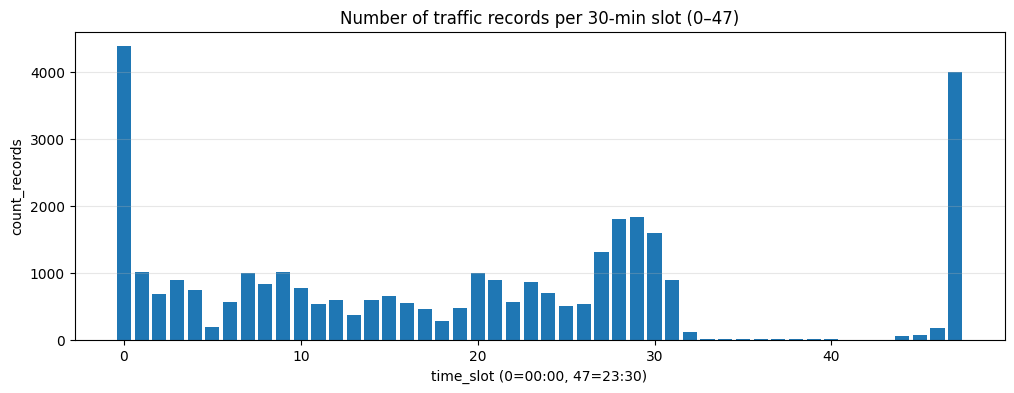

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
# Thay thế plt.plot bằng plt.bar
plt.bar(slot_table["time_slot"], slot_table["count_records"])
plt.title("Number of traffic records per 30-min slot (0–47)")
plt.xlabel("time_slot (0=00:00, 47=23:30)")
plt.ylabel("count_records")
plt.grid(axis='y', alpha=.3) # Chỉ hiển thị grid theo trục y cho biểu đồ cột
plt.show()

Nhận xét về biểu đồ:

Tuy dữ liệu thu thập theo từng khung giờ (30 phút), nhưng không phải khung giờ nào cũng có số dữ liệu bằng nhau hoặc gần bằng nhau.

Chính điều này sẽ gây khó khăn nếu muốn áp dụng các phương pháp regression/ classification theo khung giờ.



2.2.Lệch theo street

In [180]:
# Count records per segment
seg_counts = df["segment_id"].value_counts().reset_index()
seg_counts.columns = ["segment_id", "count_records"]

# Lấy mapping segment_id → street_name (mỗi segment chỉ cần 1 unique tên)
segment_street = df[["segment_id", "street_name"]].drop_duplicates(subset="segment_id")

# Merge vào bảng đếm
seg_counts = seg_counts.merge(segment_street, on="segment_id", how="left")

print(f"Tổng cổng có: {RED}{len(set(df["segment_id"]))}{RESET} đoạn đường được thu thập dữ liệu")
print(f"Top {RED}10{RESET} đoạn đường có dữ liệu nhiều nhất")
seg_counts.head(10)

Tổng cổng có: 10027 đoạn đường được thu thập dữ liệu
Top 10 đoạn đường có dữ liệu nhiều nhất


,segment_id,count_records,street_name
0,47407,54,Đường Lý Thường Kiệt
1,14522,51,Lê Thị Hà
2,3729,49,Tân Chánh Hiệp 39
3,32107,49,Tân Chánh Hiệp 2
4,3731,47,Tân Chánh Hiệp 39
5,3709,47,Tân Chánh Hiệp 39
6,21263,47,Trương Định
7,57782,45,Đường Lý Thường Kiệt
8,59128,45,Hoàng Minh Giám
9,3750,44,THOI TAM THÔN 5


In [181]:
# Count records per segment
street_counts = df["street_name"].value_counts().reset_index()
street_counts.columns = ["street_name", "count_records"]

print(f"Tổng cổng có: {RED}{len(set(df["street_name"]))}{RESET} con đường được thu thập dữ liệu")
print(f"Top {RED}10{RESET} con đường có dữ liệu nhiều nhất")
street_counts.head(10)

Tổng cổng có: 696 con đường được thu thập dữ liệu
Top 10 con đường có dữ liệu nhiều nhất


,street_name,count_records
0,Lê Đức Thọ,1389
1,Phạm Văn Đồng,1227
2,Lý Thường Kiệt,1220
3,Quang Trung,1094
4,Quốc lộ 22,976
5,Trường Chinh,973
6,Cộng Hòa,730
7,Lạc Long Quân,656
8,THOI TAM THÔN 5,619
9,Nguyễn Kiệm,565


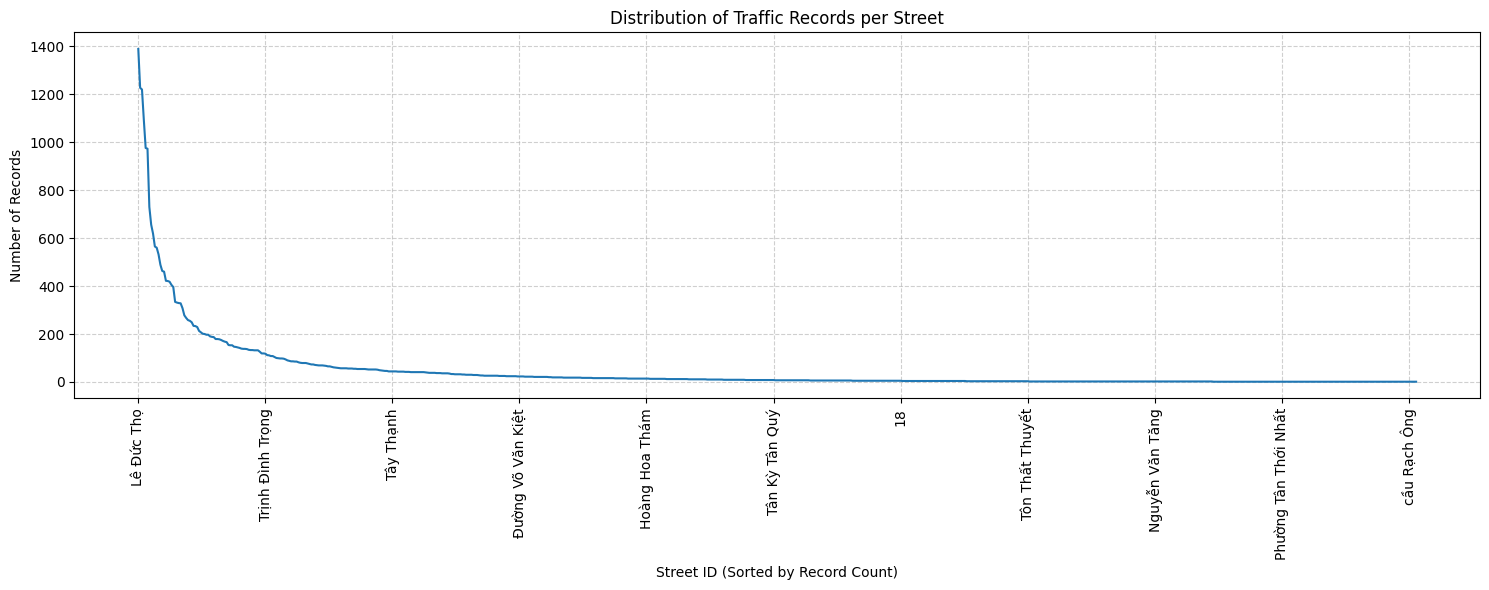

In [182]:
import matplotlib.pyplot as plt

# Assumes street_counts DataFrame from cell lpzWCiUWJGeh is available

# 1. Sắp xếp dữ liệu theo số lượng bản ghi giảm dần
street_counts_sorted = street_counts.sort_values(by="count_records", ascending=False).reset_index(drop=True)

# 2. Số hóa tên đường (tạo ID dựa trên thứ tự)
# Chúng ta có thể dùng index của DataFrame đã sort làm ID
street_counts_sorted["street_id_numeric"] = street_counts_sorted.index

# 3. Vẽ đồ thị đường
plt.figure(figsize=(15, 6)) # Điều chỉnh kích thước biểu đồ cho dễ nhìn
plt.plot(street_counts_sorted["street_id_numeric"], street_counts_sorted["count_records"])

# Đặt nhãn trục và tiêu đề
plt.xlabel("Street ID (Sorted by Record Count)")
plt.ylabel("Number of Records")
plt.title("Distribution of Traffic Records per Street")
plt.grid(True, linestyle='--', alpha=0.6)

N_display = 10 # Số lượng tên đường muốn hiển thị
plt.xticks(street_counts_sorted["street_id_numeric"][::len(street_counts_sorted)//N_display], street_counts_sorted["street_name"][::len(street_counts_sorted)//N_display], rotation=90)
plt.tight_layout() # Điều chỉnh bố cục để tránh chồng lấn nhãn
plt.show()

Nhận xét biểu đồ:

Từ biểu đồ trên, ta thấy mỗi con đường có số lượng dữ liệu thu thập khác nhau. Có thể do cách thu thập dữ liệu, có những đường dài gồm nhiều đoạn hoặc 1 đoạn đường có nhiều dữ liệu hơn các đường/ đoạn đường khác. Cũng như có nhiều đoạn đường nhỏ rất ít data.

Do đó phương pháp Dự đoán/ phân loại LOS theo đường/ đoạn đường không khả thi (cho dù có dùng SMOTE/SMOTENC hay kể cả class weight). Việc gộp nhiều đoạn đường liên tục có ít data cũng không thực tế.

Vì vậy từ tập dữ liệu, ta thấy khó thể áp dụng các phương pháp Regression/ classification vào mối tương quan LOS và street.

In [183]:
los_hour_counts = df.groupby(["time_slot","LOS"]).size().reset_index(name="count")
los_hour_counts
weekday_counts = (
    df["dow"]
    .value_counts()
    .sort_index()
    .rename_axis("dow")
    .rename("count")
    .reset_index()
)

print(weekday_counts)


   weekday  count
0        0   8112
1        1   4254
2        2   3503
3        3   3658
4        4   2011
5        5   4207
6        6   7696


/var/folders/yp/rknln0w920zfm2ythbyq3xt80000gn/T/ipykernel_52160/3146701990.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  los_hour_counts = df.groupby(["time_slot","LOS"]).size().reset_index(name="count")


/var/folders/yp/rknln0w920zfm2ythbyq3xt80000gn/T/ipykernel_52160/2605488850.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


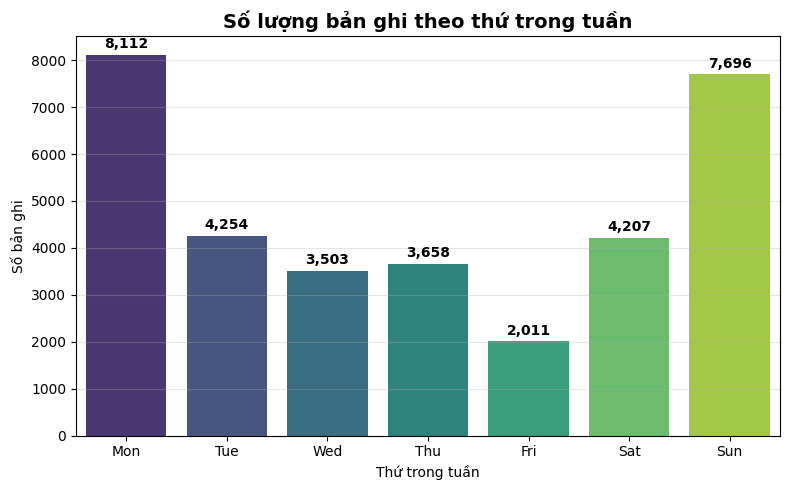

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử df đã có cột dow (day of week, 0=Mon … 6=Sun)
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

# Thống kê số lượng bản ghi theo dow
weekday_counts = (
    df["dow"]
    .value_counts()
    .sort_index()
    .rename_axis("dow")
    .rename("count")
    .reset_index()
)
weekday_counts["weekday_name"] = weekday_counts["dow"].map(weekday_map)

# --- Vẽ biểu đồ cột ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_counts,
    x="weekday_name",
    y="count",
    palette="viridis"
)

# Thêm nhãn và giá trị
plt.title("Số lượng bản ghi theo thứ trong tuần", fontsize=14, weight='bold')
plt.xlabel("Thứ trong tuần")
plt.ylabel("Số bản ghi")
plt.grid(axis="y", alpha=0.3)

# Gắn số lên đầu mỗi cột
for index, row in weekday_counts.iterrows():
    plt.text(index, row["count"] + weekday_counts["count"].max() * 0.01,
             f"{row['count']:,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Nhận xét:

data thu thập không đều giữa các ngày trong tuần.
2.4.Lệch theo tháng

In [185]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Tạo cột tháng-năm
df['year_month'] = df['date'].dt.to_period('M')

# Nhóm theo tháng-năm và đếm số lượng bản ghi
monthly_counts = df.groupby('year_month').size().reset_index(name='count')

# Hiển thị kết quả
print("Số lượng bản ghi theo từng tháng:")
display(monthly_counts)

Số lượng bản ghi theo từng tháng:


,year_month,count
0,2020-07,48
1,2020-08,7294
2,2020-09,204
3,2020-10,13
4,2020-11,5002
5,2020-12,15105
6,2021-01,2802
7,2021-02,1
8,2021-03,1743
9,2021-04,1229


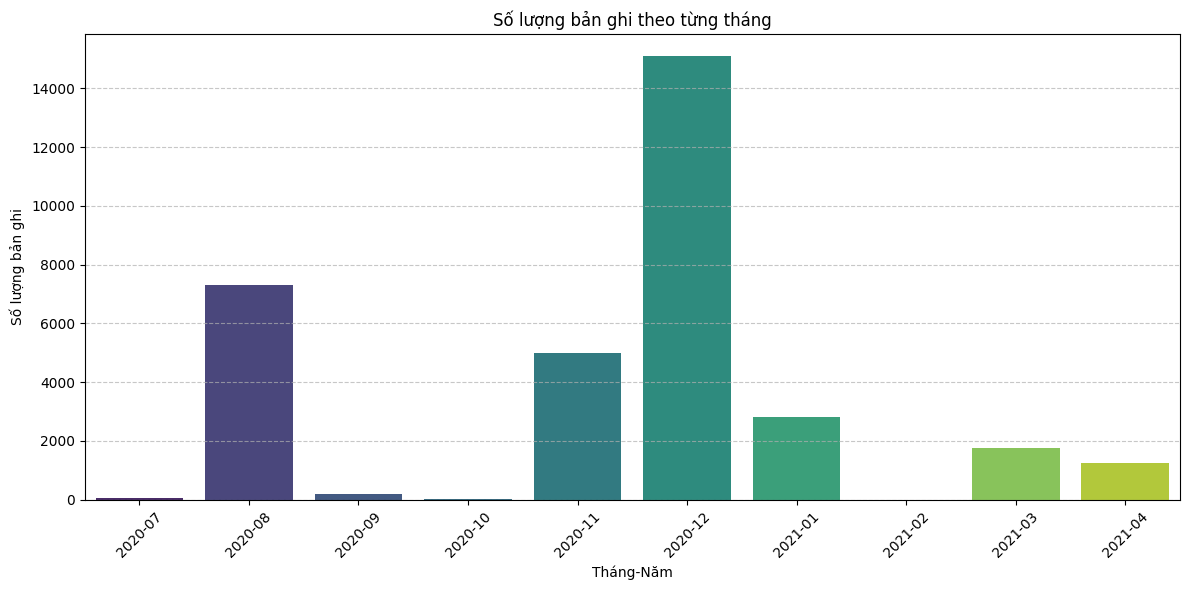

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

monthly_counts['year_month'] = monthly_counts['year_month'].astype(str)


# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
# Thêm `hue` và set `legend=False` để tránh FutureWarning
sns.barplot(data=monthly_counts, x='year_month', y='count', palette='viridis', hue='year_month', legend=False)
plt.title('Số lượng bản ghi theo từng tháng')
plt.xlabel('Tháng-Năm')
plt.ylabel('Số lượng bản ghi')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nhận xét biểu đồ:

Chúng ta thấy tập dữ liệu này không dàn trải đều theo các tháng.
Nếu áp dụng các phương pháp Regression/ classification, ta nên gộp thành 3 giai đoạn lớn theo biểu đồ thể hiện:
gian đoạn 1 gồm: tháng 7, 8, 9, 10, 11
giai đoạn 2 gồm: tháng 12
giai đoạn 3 gồm các tháng còn lại.
Tuy nhiên, cần chú ý time series có đặc tính về seasons, do đó rất khó để chia dữ liệu vào các tập train/ val/ test. Bởi vì các giai đoạn này có những hoạt động/ ngày lễ khác nhau ảnh hưởng lớn đến lưu lượng giao thông. Việc này rất khó giải quyết, ngay cả khi dùng weight class hay SMOTENC. Bởi vì sự bất cân xứng không đến từ số lượng data mà đến từ ngữ cảnh (imbalance context)/ từ bản chất của dữ liệu.

2.5.Lệch theo Covid và các ngày lễ

In [187]:
import pandas as pd
from datetime import timedelta

df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

# Danh sách ngày lễ chính (dương lịch)
base_holidays = [
    pd.to_datetime("2020-09-02").date(),  # Quốc khánh
    pd.to_datetime("2020-10-01").date(),  # Trung thu
    pd.to_datetime("2020-10-20").date(),  # Ngày phụ nữ Việt Nam
    pd.to_datetime("2020-11-20").date(),  # Ngày nhà giáo Việt Nam
]

# Mở rộng: lấy thêm 1 ngày trước và 1 ngày sau
expanded_holidays = set()
for d in base_holidays:
    for delta in range(-1, 2):  # -1, 0, 1
        expanded_holidays.add(d + timedelta(days=delta))

# (chắc chắn không vượt giới hạn 2020-07-03 → 2020-11-30)
expanded_holidays = {
    d for d in expanded_holidays
    if pd.to_datetime("2020-07-03").date() <= d <= pd.to_datetime("2020-11-30").date()
}

# Lọc các dòng tương ứng
holiday_df = df[df["date"].isin(expanded_holidays)].copy()
holiday_df = holiday_df.sort_values("date")

# Đánh dấu trong toàn tập
df["is_holiday"] = df["date"].isin(expanded_holidays)

print("Các ngày lễ (đã mở rộng):")
print(sorted(expanded_holidays))
print(f"\nTổng số dòng trùng ngày lễ (mở rộng): {len(holiday_df)}")

display(holiday_df.head())

Các ngày lễ (đã mở rộng):
[datetime.date(2020, 9, 1), datetime.date(2020, 9, 2), datetime.date(2020, 9, 3), datetime.date(2020, 9, 30), datetime.date(2020, 10, 1), datetime.date(2020, 10, 2), datetime.date(2020, 10, 19), datetime.date(2020, 10, 20), datetime.date(2020, 10, 21), datetime.date(2020, 11, 19), datetime.date(2020, 11, 20), datetime.date(2020, 11, 21)]

Tổng số dòng trùng ngày lễ (mở rộng): 621


,segment_id,date,weekday,day_type,period,time_slot,LOS,n,s_node_id,e_node_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,hour,minute,year_month
18657,47406,2020-10-19,0,weekday,period_2_00,4,F,1,4074719908,4774007052,...,4,Đường Lý Thường Kiệt,tertiary,106.660719,10.773618,106.660248,10.773370,2,0,2020-10
5541,15416,2020-10-19,0,weekday,period_2_00,4,E,1,3088844994,3088844993,...,4,Tô Hiến Thành,tertiary,106.661401,10.773618,106.661559,10.773825,2,0,2020-10
145,1558,2020-11-19,3,weekday,period_11_30,23,D,1,5719731384,3758592298,...,4,Thích Quảng Đức,tertiary,106.678519,10.808231,106.678567,10.808236,11,30,2020-11
28891,65577,2020-11-19,3,weekday,period_8_30,17,C,1,4934948014,4934948013,...,4,Đường Song Hành Xa lộ Hà Nội,tertiary,106.765896,10.834769,106.766219,10.835264,8,30,2020-11
18462,47352,2020-11-19,3,weekday,period_2_00,4,F,1,411921846,3167004172,...,4,Nguyễn Ðình Chiểu,tertiary,106.684598,10.772659,106.684535,10.772601,2,0,2020-11


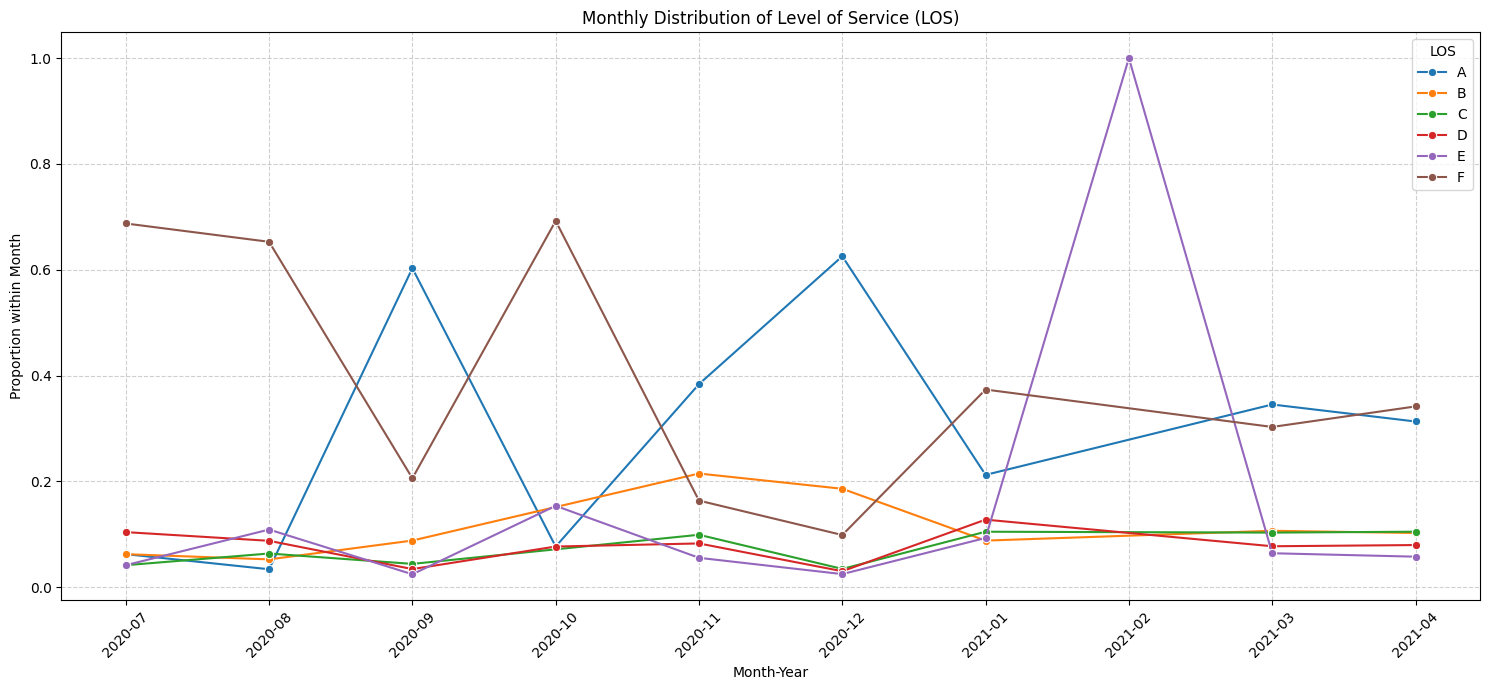

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas
import numpy as np

# Define the order of LOS categories
los_order = ["A","B","C","D","E","F"]

# 1. Tạo cột thời gian theo tháng/năm
# Đảm bảo cột 'date' là datetime objects
df['date'] = pd.to_datetime(df['date'], errors='coerce')
# Tạo cột Month-Year (chuyển sang string để vẽ biểu đồ dễ hơn)
df['year_month'] = df['date'].dt.to_period('M').astype(str) # <--- Chuyển sang string

# Ensure LOS is categorical and handle potential NaNs before grouping
df["LOS"] = pd.Categorical(df["LOS"], categories=los_order, ordered=True)
# Optional: fillna for LOS before grouping if needed, though size() handles NaNs by default
# df['LOS'] = df['LOS'].fillna('Unknown') # Example if you want to include NaNs in counts

# 2. Nhóm dữ liệu theo tháng/năm và LOS, rồi đếm
# Use observed=True to avoid FutureWarning with categorical groupers in recent pandas versions
los_monthly_counts = df.groupby(['year_month', 'LOS'], observed=True).size().reset_index(name='count')

# 3. Tính tỷ lệ phân phối LOS trong từng tháng
# Tính tổng số records mỗi tháng
monthly_total = los_monthly_counts.groupby('year_month')['count'].transform('sum')
# Tính tỷ lệ
los_monthly_counts['proportion'] = los_monthly_counts['count'] / monthly_total

# 4. Trực quan hóa sự thay đổi tỷ lệ LOS qua các tháng
plt.figure(figsize=(15, 7))
sns.lineplot(data=los_monthly_counts, x='year_month', y='proportion', hue='LOS', marker='o')

plt.title('Monthly Distribution of Level of Service (LOS)')
plt.xlabel('Month-Year')
plt.ylabel('Proportion within Month')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Nhận xét:

Như thống kê ở trên, tháng 2/2021 chỉ có 1 records về LOS, ta xem đó như nhiễu.
Theo đồ thị đường bên trên, và theo Covid, cũng như các ngày lễ, ta sẽ chia tập datasets làm ba phần:
Ngày thường trước Covid: từ tháng 7/2020 tới hết tháng 11/2021 (không bao gồm các ngày nghỉ lễ)
Ngày thường trong Covid: từ tháng 3/2021 tới hết 21/4/2021.
Phần còn lại
2.6.Chia theo 3 giai đoạn và đánh giá

In [189]:
import pandas as pd
from datetime import date

df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
holiday_df["date"] = pd.to_datetime(holiday_df["date"], errors="coerce").dt.date

holiday_dates = set(holiday_df["date"].dropna().tolist())

# ---- Các mốc thời gian ----
pre_start = date(2020, 7, 3)
pre_end   = date(2020, 11, 30)
cov_start = date(2021, 3, 1)
cov_end   = date(2021, 4, 22)

# ---- Masks ----
m_valid_date = df["date"].notna()

m_pre_range  = m_valid_date & (df["date"] >= pre_start) & (df["date"] <= pre_end)
m_pre_normal = m_pre_range & (~df["date"].isin(holiday_dates))

m_covid      = m_valid_date & (df["date"] >= cov_start) & (df["date"] <= cov_end)

# Phần còn lại: không thuộc 1 hoặc 2
m_other      = ~(m_pre_normal | m_covid)

# ---- Cắt 3 tập ----
pre_covid_df = df.loc[m_pre_normal].copy()
covid_df     = df.loc[m_covid].copy()
other_df     = df.loc[m_other].copy()

# gắn nhãn để kiểm tra / lưu
df["period_type"] = None
df.loc[m_pre_normal, "period_type"] = "pre_covid_normal"
df.loc[m_covid, "period_type"]      = "covid_period"
df.loc[m_other, "period_type"]      = "other"

print("Counts:")
print(df["period_type"].value_counts(dropna=False))

# lưu
pre_covid_df.to_csv("train_pre_covid.csv", index=False, encoding="utf-8")
covid_df.to_csv("train_covid_period.csv", index=False, encoding="utf-8")
other_df.to_csv("train_other.csv", index=False, encoding="utf-8")

Counts:
period_type
other               18529
pre_covid_normal    11940
covid_period         2972
Name: count, dtype: int64


In [190]:
import plotly.express as px

fig = px.bar(
    x=["pre_covid_normal", "covid_period", "holidays, tet"],
    y=[11940, 2972, 18529],
    labels={"x":"Giai đoạn", "y":"Số dòng dữ liệu"},
    text=[11940, 2972, 18529],
    title="Phân bố số bản ghi theo giai đoạn"
)
fig.update_traces(textposition='outside')
fig.show()

Text(0.5, 1.0, 'LOS distribution across three periods (normalized)')

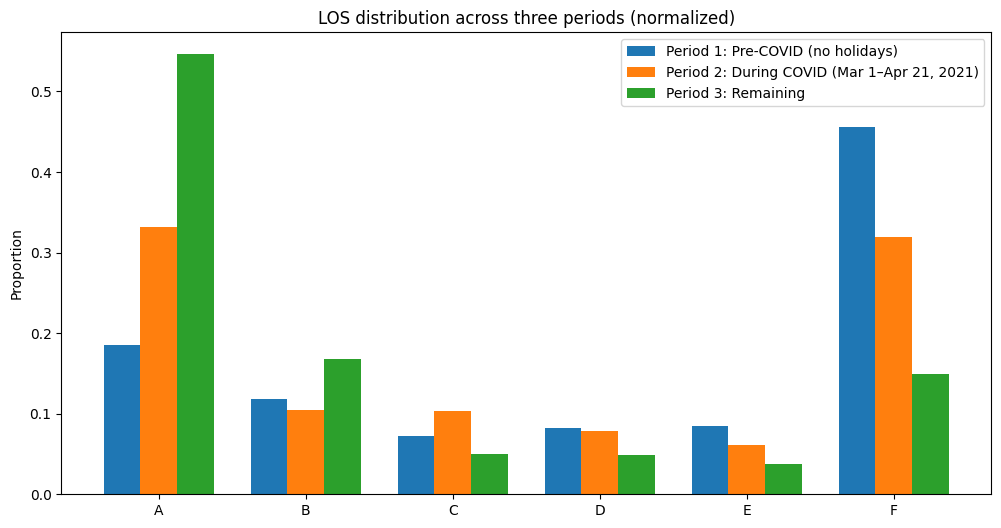

In [191]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thứ tự LOS cố định
los_order = ["A", "B", "C", "D", "E", "F"]

def los_dist(df_sub: pd.DataFrame, categories: list[str]) -> pd.Series:
    """
    Trả về tỉ lệ (0..1) của từng mức LOS trong df_sub theo thứ tự categories.
    An toàn với tập con rỗng. Không sửa df_sub gốc.
    """
    if df_sub is None or len(df_sub) == 0 or "LOS" not in df_sub.columns:
        return pd.Series([0]*len(categories), index=categories, name="proportion")

    s = pd.Series(pd.Categorical(df_sub["LOS"], categories=categories, ordered=True))
    vc = s.value_counts(sort=False)  # giữ đúng thứ tự categories
    total = int(vc.sum())
    if total == 0:
        return pd.Series([0]*len(categories), index=categories, name="proportion")
    return (vc / total).rename("proportion")

# --- Tính tỉ lệ cho 3 giai đoạn ---
p1 = los_dist(pre_covid_df, los_order).rename("proportion_p1")
p2 = los_dist(covid_df,      los_order).rename("proportion_p2")
p3 = los_dist(other_df,      los_order).rename("proportion_p3")

merged_props = (
    pd.DataFrame({"LOS": los_order})
      .merge(p1.reset_index().rename(columns={"index": "LOS"}), on="LOS", how="left")
      .merge(p2.reset_index().rename(columns={"index": "LOS"}), on="LOS", how="left")
      .merge(p3.reset_index().rename(columns={"index": "LOS"}), on="LOS", how="left")
      .fillna(0.0)
)

# --- Vẽ biểu đồ cột so sánh 3 giai đoạn (normalized) ---
x = np.arange(len(los_order))
w = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - w, merged_props["proportion_p1"].values, width=w,
        label="Period 1: Pre-COVID (no holidays)")
plt.bar(x,      merged_props["proportion_p2"].values, width=w,
        label="Period 2: During COVID (Mar 1–Apr 21, 2021)")
plt.bar(x + w,  merged_props["proportion_p3"].values, width=w,
        label="Period 3: Remaining")

plt.ylabel("Proportion")
plt.legend()
plt.xticks(x, los_order)
plt.title("LOS distribution across three periods (normalized)")

Nhận xét:

Với cách chia trên, ta thấy rằng:
trước covid, LOS F xuất hiện rất nhiều, các LOS khác tương quan gần nhau và thấp. phù hợp với xu hướng giao thông
trong Covid, LOS A và F tương quan bằng nhau, các LOS khác thấp, A nhiều chứng tỏ nhiều tuyến đường vắng hơn (do giãn cách) nhưng F nhiều cũng chứng tỏ 1 vài tuyến đường đông hơn (do các đường kia bị giãn cách nên dồn sang, hoặc các đường huyết mạch vẫn sử dụng trong giai đoạn đầu Covid). phù hợp với xu hướng giao thông
Trong ngày lễ tết, LOS A xuất hiện đa phần, phù hợp với xu hướng giao thông, thật ra vẫn có LOS F, vì vẫn còn những lưu lượng giao thông huyết mạch.
Từ đó cho thấy cách chia làm 3 giai đoạn là hợp lý.
Nhận xét chung:

Từ các số liệu trên, ta nhận thấy rằng dữ liệu bị lệch rất nhiều. Vừa lệch theo labels (LOS) vừa lệch theo context (ngày lễ, tết, covid). Đặc thù Time Series và sự phân bậc của LOS nên cũng không có nhiều cách gộp khả thi (kể cả gộp nhiều khung giờ lại thành 1 khung giờ lớn hơn).

Hướng giải quyết thứ nhất là gom những khung giờ có ít dữ liệu và liền kề nhau lại thành 1 khung giờ lớn hơn, và do đó, các phương pháp áp dụng sẽ tính trong khung giờ lớn hơn 30 phút. (khung giờ đơn vị)

Hướng giải quyết thứ hai là dùng SMOTE/ SMOTENC/ Class weight để nội suy thêm dữ liệu mới. Tuy nhiên bộ dữ liệu này vừa có các cột data liên tục vừa có các cột data rời rạc, nên khả thi nhất là dùng SMOTENC. Mặt khác, nếu dùng nội suy (SMOTENC), ta cần làm rõ cột nào là categorical (data rời rạc) và data liên tục. Data mà chúng ta đang hướng tới là cột khung thời gian, đoạn đường và cột LOS (chúng ta đang quan tâm về tương quan giữa LOS ở từng khung thời gian, từng đoạn đường). 3 cột data này thật ra là categorical, nên SMOTENC cũng không khả thi. Chỉ còn phương án dùng Class weight là an toàn nhất.

Nhưng việc áp dụng các phương pháp mà phải chia dữ liệu làm 3 tập train/ val/ test là rất khó đạt được kết quả tốt vì dữ liệu đã nhỏ còn bị chia nhiều phần, đặc thù của Time Series lại không thể áp dụng K-fold cross validation mà chỉ có thể chia theo windows extend hay sliding (đảm bảo tính trước sau của dữ liệu) càng làm giảm số lượng tập train, và rất khó lấy tập test phù hợp mà không bị ảnh hưởng bởi context (seasonal, covid).

Vì vậy, hướng tiếp cận được đề xuất là Clustering, vì:

Clustering không yêu cầu chia data thành train/ test/ val.
Clustering có thể áp dụng cho cả 3 giai đoạn thời gian trên, từng cái một, với từng ý nghĩa khác nhau, nhưng đều phản ánh tình trạng giao thông ở HCM. Từ đó cũng có căn cứ đưa ra dự báo về tình trạng giao thông ở HCM.# Add your code here